In [1]:
import polars as pl
import torch
import torch.nn as nn
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from model import *
from visualization import *
from triplet_loss import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

## Load Data and Train Model

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=512, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

47758


In [5]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([  0.5014, 180.1141])

In [6]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=20, num_neg=10, num_classes=2, latent_dim=16)

In [9]:
model

ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=20, out_features=2, bias=False)
)

In [7]:
model.proto_layer.prototype_labels_multi

tensor([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])

In [16]:
samples = []
labels = []
num_per_type = 2
for anomaly_type in range(1,6):
    indices = np.where(y_train_anomalies == anomaly_type)[0]
    chosen = np.random.permutation(indices)[:num_per_type]

    # Add to the list
    samples.append(torch.tensor(X_train[chosen], dtype=torch.float32))
    labels.append(torch.tensor(y_train_anomalies[chosen], dtype=torch.long))

X_triplet = torch.cat(samples, dim=0)
y_triplet = torch.cat(labels)


In [17]:
#lambda_triplet_values = [0.01, 0.1, 0.5, 1.0]#, 5.0, 10.0, 100.0]
#lambda_triplet_values = [5.0, 10.0, 100.0]
lambda_triplet_values = [0.5, 1.0]


for lambda_triplet in lambda_triplet_values:
    model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=20, num_neg=10, num_classes=2, latent_dim=16)
    print(f"\n Training with lambda_triplet = {lambda_triplet}")
    
    # Format lambda value for filename (e.g., 0.3 → "0_3")
    lambda_str = str(lambda_triplet).replace('.', '_')
    
    
    # Construct unique filename for this experiment
    filepath = f"model_ppnet_triplet_20_lambda_{lambda_str}.pth"
    print(f"Saving to {filepath}")
    train_protopnet_triplet(model, 
                            train_loader, 
                            val_loader, 
                            epochs=6, 
                            X_triplet=X_triplet, 
                            y_triplet=y_triplet, 
                            lr=0.0001, 
                            class_weights=class_weights, 
                            lambda_triplet=lambda_triplet, 
                            lambda_clst=0.8, 
                            lambda_sep=0.08,
                            filepath=filepath)


 Training with lambda_triplet = 0.5
Saving to model_ppnet_triplet_20_lambda_0_5.pth
0.5

Epoch 1/6


Epoch 1/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.3232
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.18558647312879326
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.1220
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.49      0.90      0.63      6708

    accuracy                           1.00   2486401
   macro avg       0.74      0.95      0.82   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8154

Epoch 2/6


Epoch 2/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.4061
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.11021136719459587
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.0794
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.50      0.94      0.65      6708

    accuracy                           1.00   2486401
   macro avg       0.75      0.97      0.83   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8267

Epoch 3/6


...

Phase 1 - Training Loss: -1.7364
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.1278463101760894
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.0942
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.69      0.93      0.79      6708

    accuracy                           1.00   2486401
   macro avg       0.84      0.96      0.89   2486401
weighted avg       1.00      1.00      1.00   2486401


Epoch 5/6


Epoch 5/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -2.4767
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.10116335077939424
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.0974
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.74      0.92      0.82      6708

    accuracy                           1.00   2486401
   macro avg       0.87      0.96      0.91   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9101

Epoch 6/6


Epoch 6/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -3.2995
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.08504243208074097
Phase 3 - Last Layer Optimization Completed
Epoch 6: Val Loss = 0.0934
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.78      0.93      0.85      6708

    accuracy                           1.00   2486401
   macro avg       0.89      0.96      0.92   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9243


In [ ]:
lambda_triplet = 0.5
filepath = "model_ppnet_best_triplet_10_lambda_0_5.pth"
train_protopnet_triplet(model, 
                        train_loader, 
                        val_loader, 
                        epochs=6, 
                        X_triplet=X_triplet, 
                        y_triplet=y_triplet, 
                        lr=0.0001, 
                        class_weights=class_weights, 
                        lambda_triplet=lambda_triplet, 
                        lambda_clst=0.8, 
                        lambda_sep=0.2,
                        filepath=filepath)

## Metrics for all lambda_triplet values

In [31]:
lambda_triplet_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]


for lambda_triplet in lambda_triplet_values:
    model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)
    print(f"\n Metrics for λ_triplet = {lambda_triplet}")
    
    lambda_str = str(lambda_triplet).replace('.', '_')
    filepath = f"model_ppnet_best_triplet_lambda_{lambda_str}.pth"
    model.load_state_dict(torch.load(filepath))

    model.eval()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    with torch.no_grad():
        _, z_train, _, y_logits = model(X_train_tensor)
        y_probs_train = F.softmax(y_logits, dim=1)
        y_pred_train = torch.argmax(y_probs_train, dim=1)
    y_pred_train = y_pred_train.cpu().numpy()
    y_probs_train = y_probs_train.cpu().numpy()
    z_train = z_train.cpu().numpy()

    model.eval()
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    with torch.no_grad():
        _, z_val, _, y_logits = model(X_val_tensor)
        y_probs_val = F.softmax(y_logits, dim=1)
        y_pred_val = torch.argmax(y_probs_val, dim=1)
    y_pred_val = y_pred_val.cpu().numpy()
    y_probs_val = y_probs_val.cpu().numpy()
    z_val = z_val.cpu().numpy()
    
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    with torch.no_grad():
        _, z_test, _, y_logits = model(X_test_tensor)
        y_probs_test = F.softmax(y_logits, dim=1)
        y_pred_test = torch.argmax(y_probs_test, dim=1)
    y_pred_test = y_pred_test.cpu().numpy()
    y_probs_test = y_probs_test.cpu().numpy()
    z_test = z_test.cpu().numpy()
    
    print(f"Training data:")

    print(classification_report(y_train, y_pred_train, digits=4))

    print(f"Validation data:")

    print(classification_report(y_val, y_pred_val, digits=4))

    print(f"Testing data:")

    print(classification_report(y_test, y_pred_test, digits=4))

    


 Metrics for λ_triplet = 0.01
Training data:
              precision    recall  f1-score   support

           0     0.9999    0.9711    0.9853  24384055
           1     0.0839    0.9511    0.1542     67879

    accuracy                         0.9710  24451934
   macro avg     0.5419    0.9611    0.5697  24451934
weighted avg     0.9973    0.9710    0.9830  24451934

Validation data:
              precision    recall  f1-score   support

           0     0.9998    0.9992    0.9995   2479693
           1     0.7661    0.9290    0.8397      6708

    accuracy                         0.9990   2486401
   macro avg     0.8829    0.9641    0.9196   2486401
weighted avg     0.9992    0.9990    0.9991   2486401

Testing data:
              precision    recall  f1-score   support

           0     0.9999    0.9979    0.9989   2759074
           1     0.5228    0.9680    0.6790      6681

    accuracy                         0.9978   2765755
   macro avg     0.7614    0.9829    0.8389   27657

## UMAP and TSNE reduction for λ_triplet = 0.5 

In [7]:
model.load_state_dict(torch.load("model_ppnet_best_triplet_lambda_0_5.pth"))

<All keys matched successfully>

In [33]:
print(confusion_matrix(y_test, y_pred_test))


[[2753529    5545]
 [    209    6472]]


In [51]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=70000, anomaly_ratio=0.1)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]
print(z_sampled.shape)

[6681]
63000
2759074
63000
(69681, 16)


In [37]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_train, y_train, n_samples=200000, anomaly_ratio=0.2)
y_pred_sampled = y_pred_train[selected_indices]
y_train_anomalies_sampled = y_train_anomalies[selected_indices]
print(z_sampled.shape)

[67879]
160000
24384055
160000
torch.Size([200000, 16])


### Training data

In [38]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(200000, 2)

In [39]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(15, 2)

In [105]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train_tensor)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

# for i, dist in enumerate(distances):
#     print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")
print(f"Anomaly prototypes indexes: {y_train_anomalies[closest_indices[-10:]]}")

Anomaly prototypes indexes: [1 1 2 2 3 3 4 4 5 5]


In [36]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]
proto_colors = [custom_palette[label] for label in y_train_anomalies[closest_indices]]

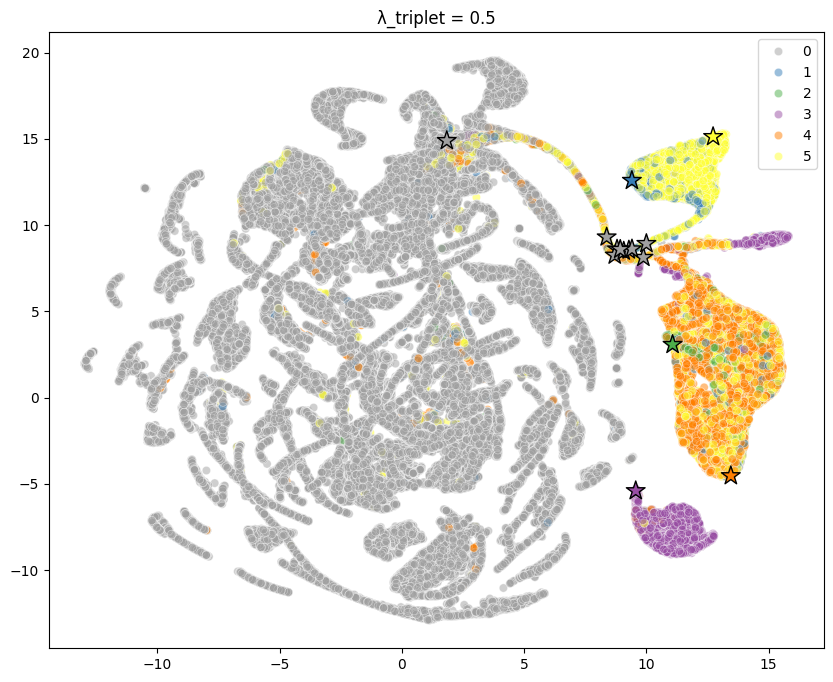

In [40]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

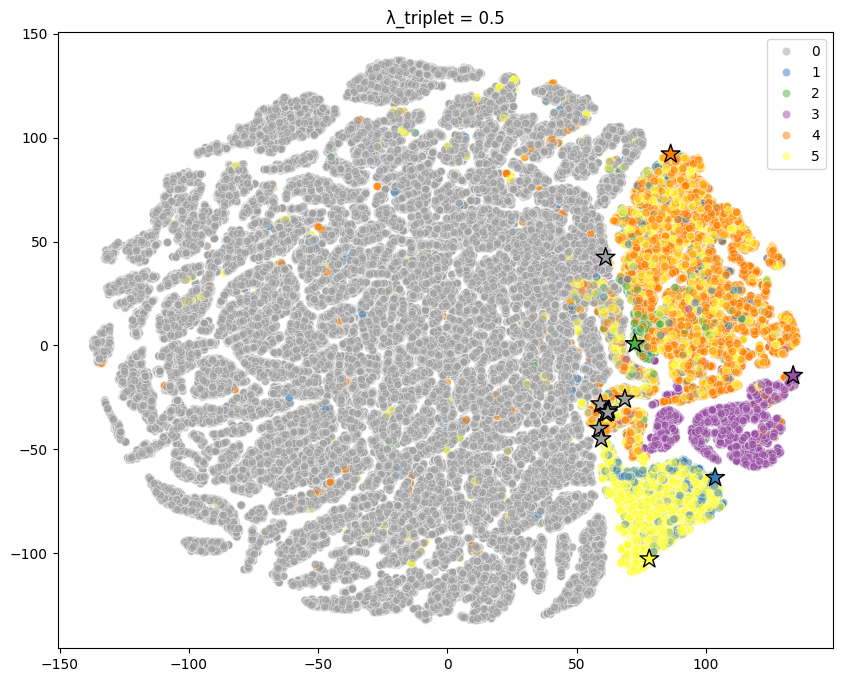

In [41]:
z_combined = np.vstack([z_sampled, prototypes])
tsne = TSNE(n_components=2)
embedding_combined = tsne.fit_transform(z_combined)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_combined[:-15, 0], y=embedding_combined[:-15, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(embedding_combined[-15:, 0], embedding_combined[-15:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

plt.title("λ_triplet = 0.5")
plt.legend()
plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled_tsne.png")
plt.show()

### Testing data

In [53]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
print(embedding.shape)

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(69681, 2)


In [54]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(15, 2)

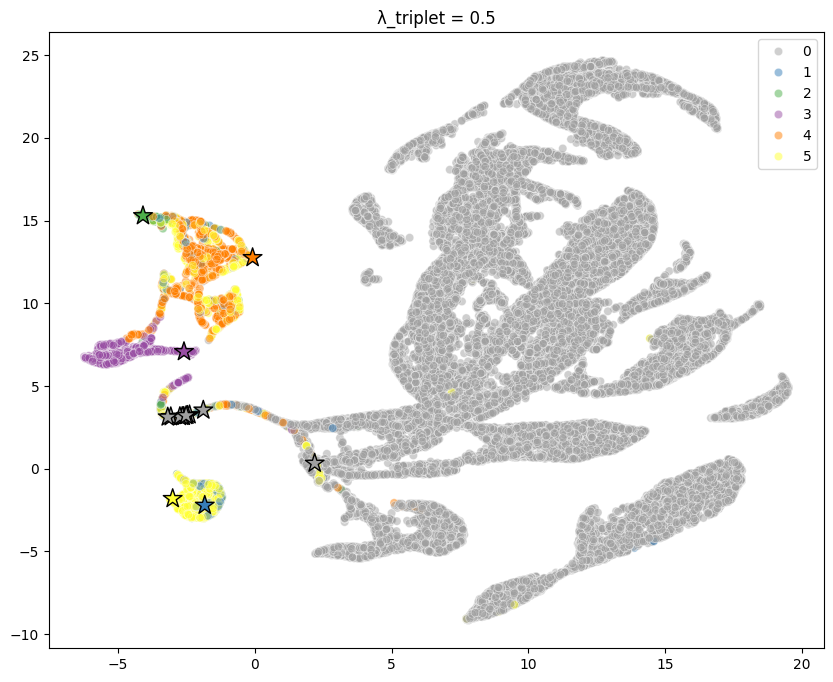

In [55]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

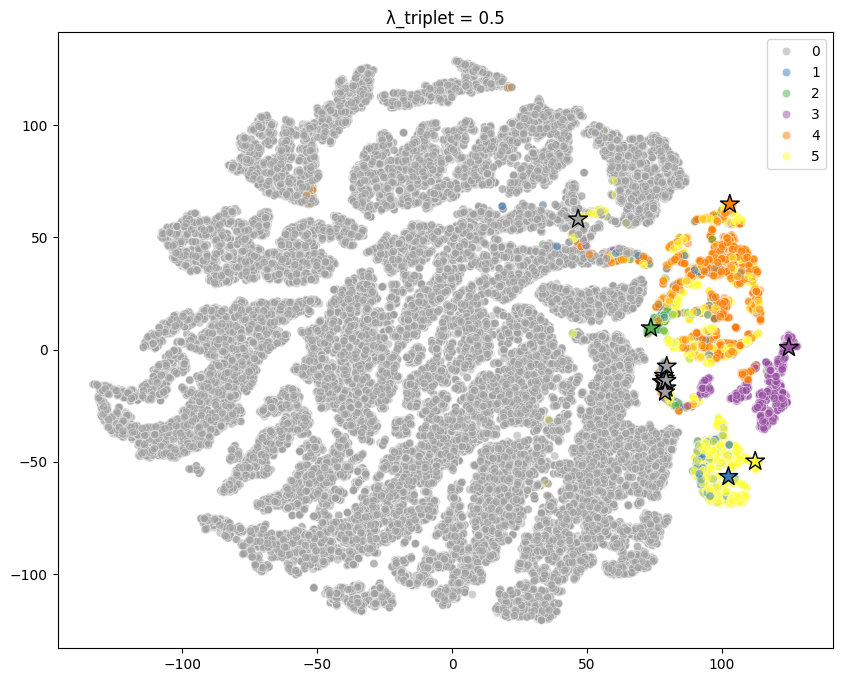

In [52]:
z_combined = np.vstack([z_sampled, prototypes])
tsne = TSNE(n_components=2)
embedding_combined = tsne.fit_transform(z_combined)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_combined[:-15, 0], y=embedding_combined[:-15, 1], hue=y_test_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(embedding_combined[-15:, 0], embedding_combined[-15:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled_tsne.png")
plt.show()

## UMAP and TSNE reduction for λ_triplet = 0.5 (number of prtotypes for each anomaly type = 2)

In [10]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=20, num_neg=10, num_classes=2, latent_dim=16)
model.load_state_dict(torch.load("model_ppnet_triplet_20_lambda_0_5.pth"))

<All keys matched successfully>

In [11]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, z_train, distances, y_logits = model(X_train_tensor)
    y_probs_train = F.softmax(y_logits, dim=1)
    y_pred_train = torch.argmax(y_probs_train, dim=1)
y_pred_train = y_pred_train.cpu().numpy()
y_probs_train = y_probs_train.cpu().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()

model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, distances, y_logits = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()

model.eval()
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
with torch.no_grad():
    _, z_val, distances, y_logits = model(X_val_tensor)
    y_probs_val = F.softmax(y_logits, dim=1)
    y_pred_val = torch.argmax(y_probs_val, dim=1)
y_pred_val = y_pred_val.cpu().numpy()
y_probs_val = y_probs_val.cpu().numpy()
print(y_pred_val.shape)
z_val = z_val.cpu().numpy()


(24451934,)
(2765755,)
(2486401,)


In [12]:
print(classification_report(y_train, y_pred_train, digits=4))
print(classification_report(y_val, y_pred_val, digits=4))
print(classification_report(y_test, y_pred_test, digits=4))


              precision    recall  f1-score   support

           0     0.9999    0.9902    0.9950  24384055
           1     0.2127    0.9483    0.3475     67879

    accuracy                         0.9901  24451934
   macro avg     0.6063    0.9693    0.6713  24451934
weighted avg     0.9977    0.9901    0.9932  24451934

              precision    recall  f1-score   support

           0     0.9998    0.9993    0.9996   2479693
           1     0.7917    0.9270    0.8540      6708

    accuracy                         0.9991   2486401
   macro avg     0.8958    0.9631    0.9268   2486401
weighted avg     0.9992    0.9991    0.9992   2486401

              precision    recall  f1-score   support

           0     0.9999    0.9987    0.9993   2759074
           1     0.6475    0.9578    0.7726      6681

    accuracy                         0.9986   2765755
   macro avg     0.8237    0.9783    0.8860   2765755
weighted avg     0.9990    0.9986    0.9988   2765755



In [24]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train_tensor)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

# for i, dist in enumerate(distances):
#     print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")
print(f"Anomaly prototypes indices: {y_train_anomalies[closest_indices]}")

Anomaly prototypes indices: [0 0 0 0 0 0 0 0 0 0 1 2 3 4 5]


In [16]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]
proto_colors = [custom_palette[label] for label in y_train_anomalies[closest_indices]]

In [17]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_train, y_train, n_samples=200000, anomaly_ratio=0.2)
y_pred_sampled = y_pred_train[selected_indices]
y_train_anomalies_sampled = y_train_anomalies[selected_indices]
print(z_sampled.shape)

prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
print(embedding.shape)

prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
print(prototype_embedding.shape)

[67879]
160000
24384055
160000
torch.Size([200000, 16])


/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(200000, 2)


/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(20, 2)


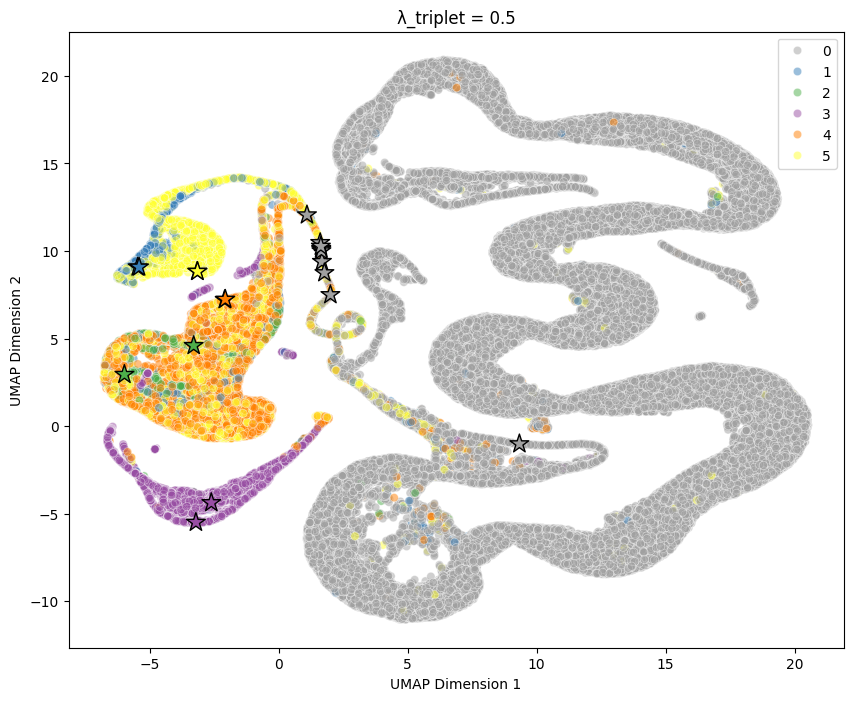

In [21]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

# Plot prototypes as red stars
plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("λ_triplet = 0.5")
plt.legend()
plt.show()

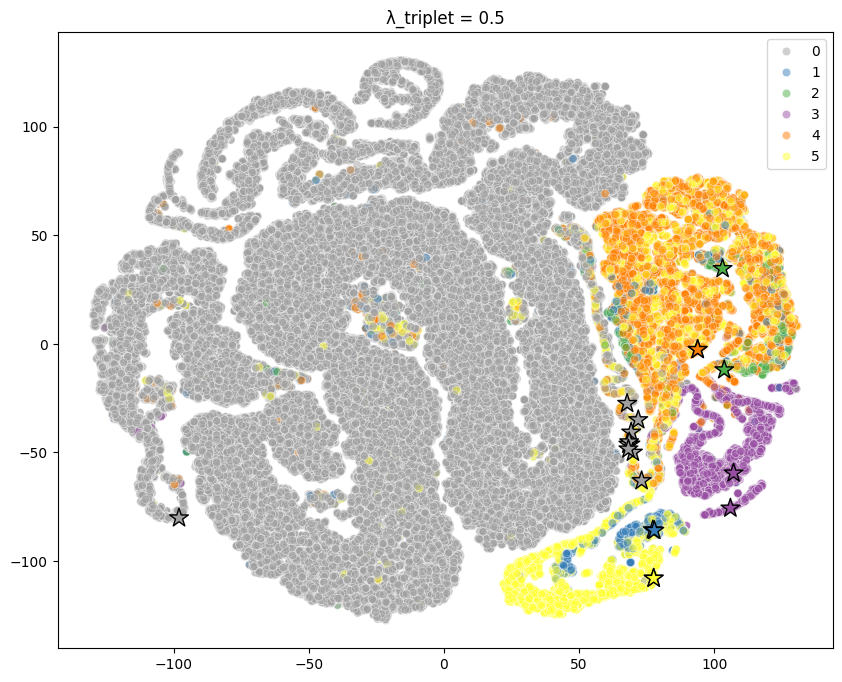

In [20]:
z_combined = np.vstack([z_sampled, prototypes])
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedding_combined = tsne.fit_transform(z_combined)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_combined[:-20, 0], y=embedding_combined[:-20, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

# Plot prototypes as red stars
plt.scatter(embedding_combined[-20:, 0], embedding_combined[-20:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled_tsne.png")
plt.show()

## Find Best Threshold

In [6]:
lambda_triplet = 0.5

model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)
print(f"\n Metrics for λ_triplet = {lambda_triplet} before thresholding:")

lambda_str = str(lambda_triplet).replace('.', '_')
filepath = f"model_ppnet_best_triplet_lambda_{lambda_str}.pth"
model.load_state_dict(torch.load(filepath))

model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, z_train, _, y_logits = model(X_train_tensor)
    y_probs_train = F.softmax(y_logits, dim=1)
    y_pred_train = torch.argmax(y_probs_train, dim=1)
y_pred_train = y_pred_train.cpu().numpy()
y_probs_train = y_probs_train.cpu().numpy()
z_train = z_train.cpu().numpy()

model.eval()
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
with torch.no_grad():
    _, z_val, _, y_logits = model(X_val_tensor)
    y_probs_val = F.softmax(y_logits, dim=1)
    y_pred_val = torch.argmax(y_probs_val, dim=1)
y_pred_val = y_pred_val.cpu().numpy()
y_probs_val = y_probs_val.cpu().numpy()
z_val = z_val.cpu().numpy()
    
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, _, y_logits = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
z_test = z_test.cpu().numpy()

print(f"Training data:")
print(classification_report(y_train, y_pred_train, digits=4))
print(f"Validation data:")
print(classification_report(y_val, y_pred_val, digits=4))
print(f"Testing data:")
print(classification_report(y_test, y_pred_test, digits=4))


 Metrics for λ_triplet = 0.5 before thresholding:
Training data:
              precision    recall  f1-score   support

           0     0.9998    0.9972    0.9985  24384055
           1     0.4830    0.9321    0.6362     67879

    accuracy                         0.9970  24451934
   macro avg     0.7414    0.9646    0.8174  24451934
weighted avg     0.9984    0.9970    0.9975  24451934

Validation data:
              precision    recall  f1-score   support

           0     0.9998    0.9993    0.9995   2479693
           1     0.7695    0.9128    0.8350      6708

    accuracy                         0.9990   2486401
   macro avg     0.8846    0.9560    0.9173   2486401
weighted avg     0.9991    0.9990    0.9991   2486401

Testing data:
              precision    recall  f1-score   support

           0     0.9999    0.9953    0.9976   2759074
           1     0.3316    0.9717    0.4944      6681

    accuracy                         0.9952   2765755
   macro avg     0.6657    0.98

In [8]:
best_f1, best_threshold = f1_smart(y_val, y_probs_val[:, 1])
best_threshold

np.float32(0.9658997)

In [142]:
print(f"\n Metrics for λ_triplet = {lambda_triplet} after thresholding:\n")
print(f"Training data:")
print(classification_report(y_train, y_probs_train[:, 1] > best_threshold, digits=4))
print(f"Validation data:")
print(classification_report(y_val, y_probs_val[:, 1] > best_threshold, digits=4))
print(f"Testing data:")
print(classification_report(y_test, y_probs_test[:, 1] > best_threshold, digits=4))


 Metrics for λ_triplet = 0.5 after thresholding:

Training data:
              precision    recall  f1-score   support

           0     0.9997    0.9992    0.9994  24384055
           1     0.7483    0.8904    0.8132     67879

    accuracy                         0.9989  24451934
   macro avg     0.8740    0.9448    0.9063  24451934
weighted avg     0.9990    0.9989    0.9989  24451934

Validation data:
              precision    recall  f1-score   support

           0     0.9996    0.9995    0.9996   2479693
           1     0.8360    0.8699    0.8526      6708

    accuracy                         0.9992   2486401
   macro avg     0.9178    0.9347    0.9261   2486401
weighted avg     0.9992    0.9992    0.9992   2486401

Testing data:
              precision    recall  f1-score   support

           0     0.9998    0.9991    0.9995   2759074
           1     0.7174    0.9328    0.8110      6681

    accuracy                         0.9990   2765755
   macro avg     0.8586    0.96

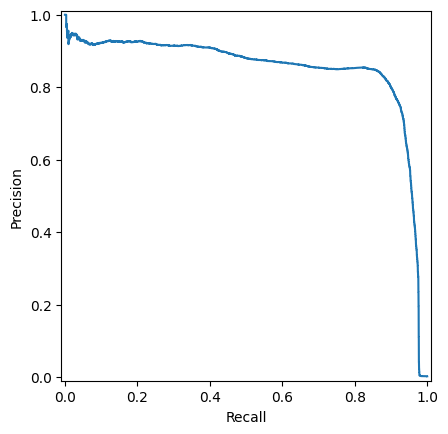

In [76]:
precision, recall, _ = precision_recall_curve(y_test, y_probs_test[:, 1])
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

## Anomaly Type Assignment via Prototype Proximity

In [23]:
prototypes = model.proto_layer.prototypes[model.proto_layer.prototype_labels != 0]
prototypes.shape

torch.Size([5, 16])

In [73]:
# Compute the distance between the latent representation of a fraudulent sample and each of the anomaly prototypes
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, _, y_logits = model(X_test_tensor)

### Classifying True Anomalies
Choose fraudulent samples from test data for classification

In [42]:
prototypes = model.proto_layer.prototypes
labels = torch.cat((torch.zeros(10, dtype=torch.long), model.proto_layer.prototype_labels_multi))
y_test_true = y_test_anomalies[y_test_anomalies != 0]
dists = torch.cdist(prototypes, z_test[y_test_anomalies != 0])
y_pred_multi_test = torch.argmin(dists, dim=0)
y_pred_multi_test.shape

torch.Size([6681])

In [43]:
# Initially y_pred_multi_test contains indices of the labels
y_pred_multi_test = labels[y_pred_multi_test]

In [60]:
y_pred_multi_test[y_pred_multi_test == 0].size()

torch.Size([543])

In [57]:
# Metrics including anomalies misclassified as normal
print(classification_report(y_test_true, y_pred_multi_test, digits=4, zero_division=0.0))
print(confusion_matrix(y_test_true, y_pred_multi_test))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.1748    0.4028    0.2438       576
           2     0.6024    0.5953    0.5988       257
           3     0.9180    0.9617    0.9393      1175
           4     0.6073    0.8739    0.7166      2228
           5     0.8250    0.0405    0.0772      2445

    accuracy                         0.5330      6681
   macro avg     0.5212    0.4790    0.4293      6681
weighted avg     0.7041    0.5330    0.4765      6681

[[   0    0    0    0    0    0]
 [ 115  232   16    0  207    6]
 [  36   11  153    2   46    9]
 [  15   21    0 1130    7    2]
 [ 147   16   35   79 1947    4]
 [ 230 1047   50   20  999   99]]


In [61]:
# Metrics excluding anomalies misclassified as normal
print(classification_report(y_test_true[y_pred_multi_test != 0], y_pred_multi_test[y_pred_multi_test != 0], digits=4, zero_division=0.0))
print(confusion_matrix(y_test_true[y_pred_multi_test != 0], y_pred_multi_test[y_pred_multi_test != 0]))

              precision    recall  f1-score   support

           1     0.1748    0.5033    0.2595       461
           2     0.6024    0.6923    0.6442       221
           3     0.9180    0.9741    0.9452      1160
           4     0.6073    0.9356    0.7365      2081
           5     0.8250    0.0447    0.0848      2215

    accuracy                         0.5802      6138
   macro avg     0.6255    0.6300    0.5340      6138
weighted avg     0.7119    0.5802    0.5016      6138

[[ 232   16    0  207    6]
 [  11  153    2   46    9]
 [  21    0 1130    7    2]
 [  16   35   79 1947    4]
 [1047   50   20  999   99]]


In [65]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_test[y_test_anomalies != 0])
print(embedding.shape)

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(6681, 2)


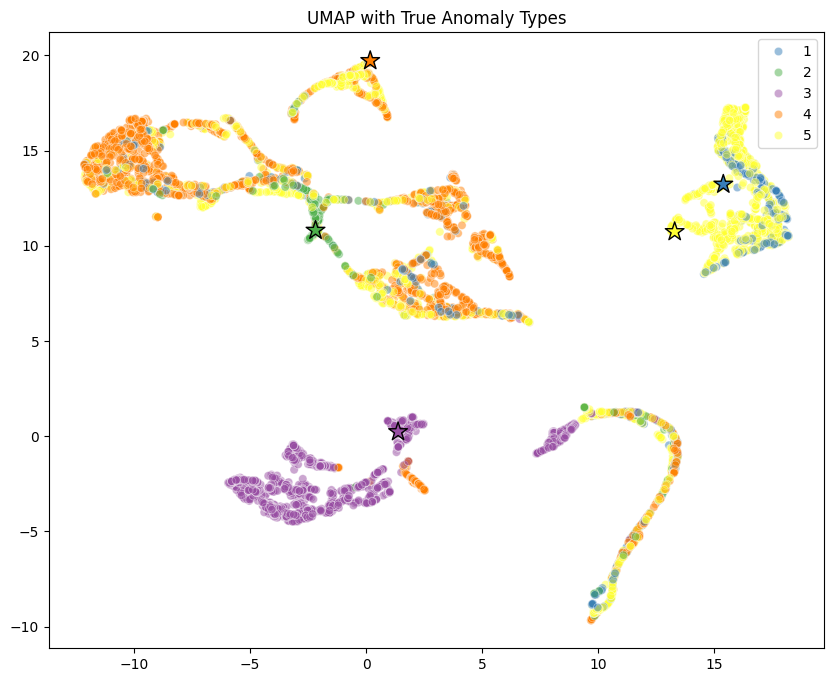

In [67]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_true, alpha=0.5, palette=custom_palette[1:])

plt.scatter(prototype_embedding[-5:, 0], prototype_embedding[-5:, 1], c=proto_colors[-5:], marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("UMAP with True Anomaly Types")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

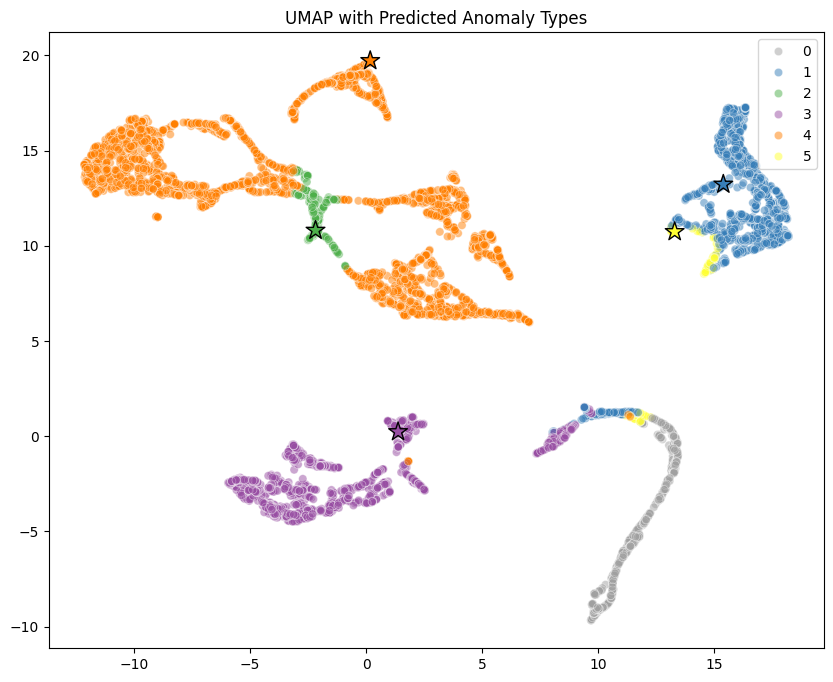

In [70]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_multi_test, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[-5:, 0], prototype_embedding[-5:, 1], c=proto_colors[-5:], marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("UMAP with Predicted Anomaly Types")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

### Classifying Predicted Anomalies
Choose samples classified by the model as fraud (class 1) for further classification into anomaly types

In [84]:
# Assign the anomaly sample the type (label) of the closest prototype (the one with the minimal distance).
prototypes = model.proto_layer.prototypes[-5:]
dists = torch.cdist(prototypes, z_test[y_probs_test[:, 1] > best_threshold])
y_pred_multi_test = torch.argmin(dists, dim=0) + 1 # classes from 1 to 5
y_pred_multi_test.shape

torch.Size([8687])

In [85]:
y_test_true = y_test_anomalies[y_probs_test[:, 1] > best_threshold]
y_test_true.shape

(8687,)

In [86]:
# Classification report including samples of class 0 misclassified by the model as anomalies
print(classification_report(y_test_true, y_pred_multi_test, digits=4, zero_division=0.0))
print(confusion_matrix(y_test_true, y_pred_multi_test))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      2455
           1     0.1057    0.4833    0.1735       480
           2     0.5752    0.6740    0.6207       227
           3     0.7913    0.9733    0.8729      1161
           4     0.5040    0.9289    0.6535      2096
           5     0.1626    0.0670    0.0949      2268

    accuracy                         0.4160      8687
   macro avg     0.3565    0.5211    0.4026      8687
weighted avg     0.2907    0.4160    0.3249      8687

[[   0  868   12  197  657  721]
 [   0  232   16    0  207   25]
 [   0   11  153    2   46   15]
 [   0   21    0 1130    7    3]
 [   0   16   35   79 1947   19]
 [   0 1047   50   20  999  152]]


In [88]:
# Classification report excluding samples of class 0 misclassified by the model as anomalies
print(classification_report(y_test_true[y_test_true != 0], y_pred_multi_test[y_test_true != 0], digits=4))
print(confusion_matrix(y_test_true[y_test_true != 0], y_pred_multi_test[y_test_true != 0]))

              precision    recall  f1-score   support

           1     0.1748    0.4833    0.2568       480
           2     0.6024    0.6740    0.6362       227
           3     0.9180    0.9733    0.9448      1161
           4     0.6073    0.9289    0.7344      2096
           5     0.7103    0.0670    0.1225      2268

    accuracy                         0.5799      6232
   macro avg     0.6025    0.6253    0.5389      6232
weighted avg     0.6692    0.5799    0.5106      6232

[[ 232   16    0  207   25]
 [  11  153    2   46   15]
 [  21    0 1130    7    3]
 [  16   35   79 1947   19]
 [1047   50   20  999  152]]


In [106]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]
proto_colors = [custom_palette[label] for label in y_train_anomalies[closest_indices]]

In [90]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_test[y_probs_test[:, 1] > best_threshold])
print(embedding.shape)

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(8687, 2)


In [91]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(15, 2)

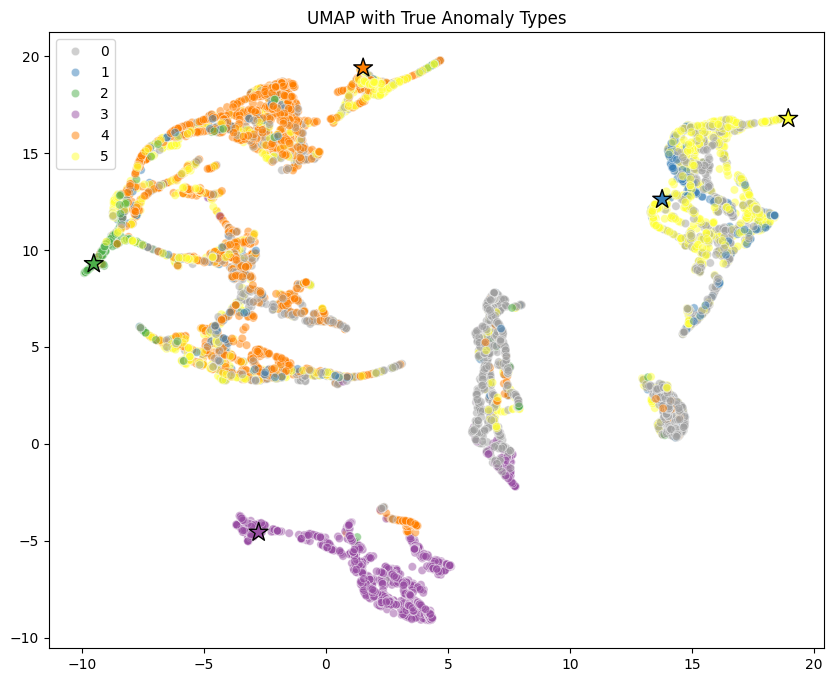

In [92]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_true, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[-5:, 0], prototype_embedding[-5:, 1], c=proto_colors[-5:], marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("UMAP with True Anomaly Types")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

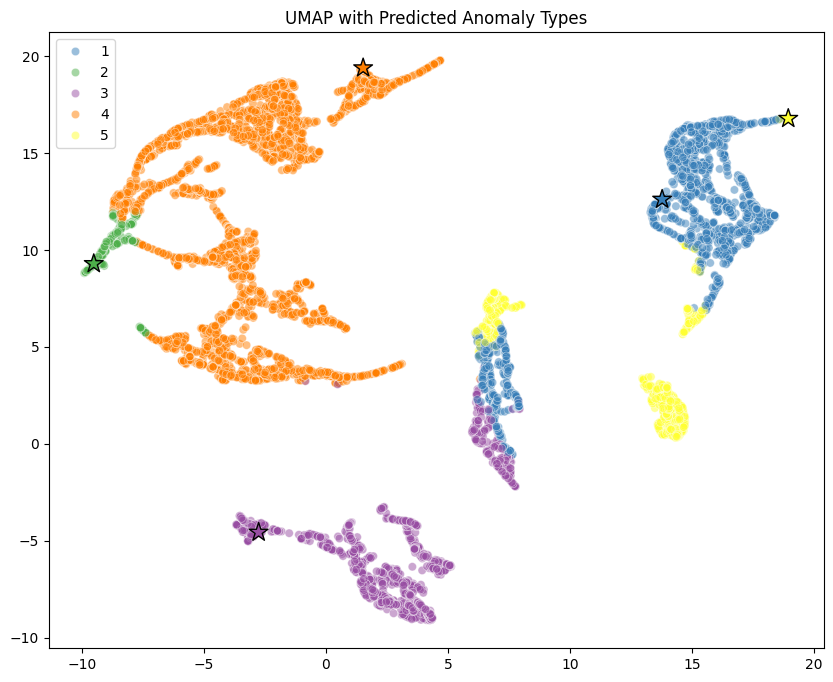

In [93]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_multi_test, alpha=0.5, palette=custom_palette[1:])

plt.scatter(prototype_embedding[-5:, 0], prototype_embedding[-5:, 1], c=proto_colors[-5:], marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("UMAP with Predicted Anomaly Types")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

## Similar Analysis for the Model with Two Prototypes for Each Anomaly Type
While the overall performance metrics for classification into anomaly types via prototype proximity declined with the model using two prototypes per anomaly type, it showed notable improvement in correctly classifying anomaly types 1 and 5, which had been the most challenging in the earlier setup.

In [95]:
lambda_triplet = 0.5

model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=20, num_neg=10, num_classes=2, latent_dim=16)
print(f"\n Metrics for λ_triplet = {lambda_triplet} before thresholding:")

lambda_str = str(lambda_triplet).replace('.', '_')
filepath = f"model_ppnet_triplet_20_lambda_{lambda_str}.pth"
model.load_state_dict(torch.load(filepath))

model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, z_train, _, y_logits = model(X_train_tensor)
    y_probs_train = F.softmax(y_logits, dim=1)
    y_pred_train = torch.argmax(y_probs_train, dim=1)
y_pred_train = y_pred_train.cpu().numpy()
y_probs_train = y_probs_train.cpu().numpy()
z_train = z_train.cpu().numpy()

model.eval()
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
with torch.no_grad():
    _, z_val, _, y_logits = model(X_val_tensor)
    y_probs_val = F.softmax(y_logits, dim=1)
    y_pred_val = torch.argmax(y_probs_val, dim=1)
y_pred_val = y_pred_val.cpu().numpy()
y_probs_val = y_probs_val.cpu().numpy()
z_val = z_val.cpu().numpy()
    
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, _, y_logits = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
z_test = z_test.cpu().numpy()

best_f1, best_threshold = f1_smart(y_val, y_probs_val[:, 1])
best_threshold

print(f"\n Metrics for λ_triplet = {lambda_triplet} after thresholding:\n")
print(f"Training data:")
print(classification_report(y_train, y_probs_train[:, 1] > best_threshold, digits=4))
print(f"Validation data:")
print(classification_report(y_val, y_probs_val[:, 1] > best_threshold, digits=4))
print(f"Testing data:")
print(classification_report(y_test, y_probs_test[:, 1] > best_threshold, digits=4))


 Metrics for λ_triplet = 0.5 before thresholding:

 Metrics for λ_triplet = 0.5 after thresholding:

Training data:
              precision    recall  f1-score   support

           0     0.9998    0.9936    0.9967  24384055
           1     0.2881    0.9364    0.4406     67879

    accuracy                         0.9934  24451934
   macro avg     0.6440    0.9650    0.7187  24451934
weighted avg     0.9978    0.9934    0.9951  24451934

Validation data:
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9996   2479693
           1     0.8203    0.9088    0.8623      6708

    accuracy                         0.9992   2486401
   macro avg     0.9101    0.9541    0.9310   2486401
weighted avg     0.9993    0.9992    0.9992   2486401

Testing data:
              precision    recall  f1-score   support

           0     0.9999    0.9992    0.9995   2759074
           1     0.7368    0.9427    0.8271      6681

    accuracy                      

Choose samples classified by the model as fraud (class 1) for further classification into anomaly types

In [99]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, z_test, _, y_logits = model(X_test_tensor)

prototypes = model.proto_layer.prototypes[-10:]
dists = torch.cdist(prototypes, z_test[y_probs_test[:, 1] > best_threshold])
y_pred_multi_test = torch.argmin(dists, dim=0) # classes from 1 to 5
y_pred_multi_test = model.proto_layer.prototype_labels_multi[y_pred_multi_test]

y_test_true = y_test_anomalies[y_probs_test[:, 1] > best_threshold]
y_test_true.shape

(8548,)

In [100]:
# Classification report including samples of class 0 misclassified by the model as anomalies
print(classification_report(y_test_true, y_pred_multi_test, digits=4, zero_division=0.0))
print(confusion_matrix(y_test_true, y_pred_multi_test))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      2250
           1     0.3486    0.3901    0.3682       487
           2     0.0529    0.8782    0.0998       238
           3     0.9030    0.9629    0.9320      1160
           4     0.2956    0.0378    0.0670      2143
           5     0.3640    0.4075    0.3845      2270

    accuracy                         0.2950      8548
   macro avg     0.3274    0.4461    0.3086      8548
weighted avg     0.3147    0.2950    0.2692      8548

[[   0   99  506   63  134 1448]
 [   0  190  214    0    7   76]
 [   0    0  209    3    0   26]
 [   0    0   35 1117    2    6]
 [   0    0 1968   34   81   60]
 [   0  256 1019   20   50  925]]


In [101]:
# Classification report excluding samples of class 0 misclassified by the model as anomalies
print(classification_report(y_test_true[y_test_true != 0], y_pred_multi_test[y_test_true != 0], digits=4))
print(confusion_matrix(y_test_true[y_test_true != 0], y_pred_multi_test[y_test_true != 0]))

              precision    recall  f1-score   support

           1     0.4260    0.3901    0.4073       487
           2     0.0607    0.8782    0.1135       238
           3     0.9514    0.9629    0.9572      1160
           4     0.5786    0.0378    0.0710      2143
           5     0.8463    0.4075    0.5501      2270

    accuracy                         0.4004      6298
   macro avg     0.5726    0.5353    0.4198      6298
weighted avg     0.7124    0.4004    0.4345      6298

[[ 190  214    0    7   76]
 [   0  209    3    0   26]
 [   0   35 1117    2    6]
 [   0 1968   34   81   60]
 [ 256 1019   20   50  925]]


In [102]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_test[y_probs_test[:, 1] > best_threshold])
print(embedding.shape)

prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape


/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(8548, 2)


/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(20, 2)

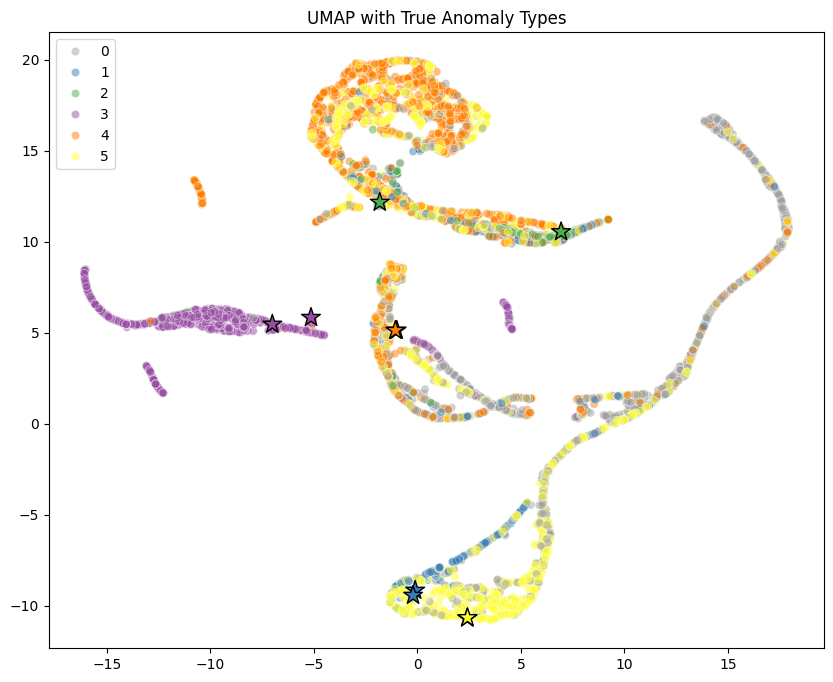

In [107]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_true, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[-10:, 0], prototype_embedding[-10:, 1], c=proto_colors[-10:], marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("UMAP with True Anomaly Types")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

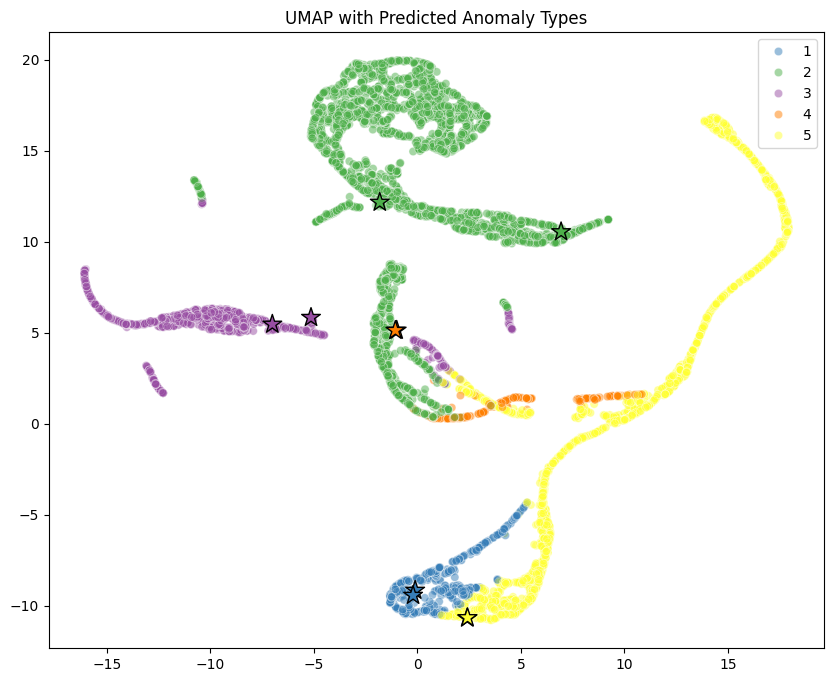

In [108]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_pred_multi_test, alpha=0.5, palette=custom_palette[1:])

plt.scatter(prototype_embedding[-10:, 0], prototype_embedding[-10:, 1], c=proto_colors[-10:], marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("UMAP with Predicted Anomaly Types")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()